In [1]:
# COMPLETE SETUP CELL - Run this FIRST

from google.colab import drive
import os

# Mount Drive (skip if already mounted)
try:
    drive.mount('/content/drive', force_remount=False)
except:
    pass  # Already mounted

# Navigate to project folder
# Update this path to match your project location in Google Drive
project_path = '/content/drive/MyDrive/DLP_project'  # Change this to your actual path
os.chdir(project_path)

# Change to notebooks folder (so ../results/ and ../data/ paths work)
os.chdir('notebooks')

print(f"Current directory: {os.getcwd()}")
print(f"Can access data/processed: {os.path.exists('../data/processed')}")
print(f"Can access results: {os.path.exists('../results')}")


Mounted at /content/drive
Current directory: /content/drive/MyDrive/DLP_project/notebooks
Can access data/processed: True
Can access results: True


# Dataset Preprocessing

This notebook loads the Urdu Poetry Dataset from HuggingFace, preprocesses it, and prepares it for training language models.


In [2]:
# Install required libraries
!pip install -q datasets transformers tensorflow numpy pandas matplotlib


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle
import re

# Set random seeds for reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

# Create directories if they don't exist
os.makedirs('../data/processed', exist_ok=True)


## Load Dataset from HuggingFace


In [4]:
# Load the Urdu Poetry Dataset
dataset = load_dataset("ReySajju742/Urdu-Poetry-Dataset")

print("Dataset loaded successfully!")
print(f"Dataset splits: {dataset.keys()}")
print(f"Dataset info: {dataset}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

output_ur.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1323 [00:00<?, ? examples/s]

Dataset loaded successfully!
Dataset splits: dict_keys(['train'])
Dataset info: DatasetDict({
    train: Dataset({
        features: ['title', 'content'],
        num_rows: 1323
    })
})


## Extract and Clean Text


In [5]:
# Extract all text from the dataset
all_lines = []

# Check the structure of the dataset
if 'train' in dataset:
    split_data = dataset['train']
elif 'poem' in dataset:
    split_data = dataset['poem']
else:
    # Try to get the first available split
    split_data = dataset[list(dataset.keys())[0]]

# Extract text - handle different possible column names
text_column = None
for col in ['poem', 'text', 'content', 'verse', 'line']:
    if col in split_data.column_names:
        text_column = col
        break

if text_column is None:
    # If no standard column found, use the first text-like column
    text_column = split_data.column_names[0]

print(f"Using column: {text_column}")

# Extract individual lines
for item in split_data:
    text = item[text_column]
    if isinstance(text, str):
        # Split by newlines to get individual lines
        lines = text.split('\n')
        for line in lines:
            line = line.strip()
            if line:  # Only add non-empty lines
                all_lines.append(line)

print(f"Total lines extracted: {len(all_lines)}")
print(f"Sample lines:")
for i in range(min(5, len(all_lines))):
    print(f"  {i+1}. {all_lines[i]}")


Using column: content
Total lines extracted: 21068
Sample lines:
  1. بے ٹھکانے ہے دل غمگیں ٹھکانے کی کہو
  2. شام ہجراں دوستو کچھ اس کے آنے کی کہو
  3. ہاں نہ پوچھ اک گرفتار قفس کی زندگی
  4. ہم صفیران چمن کچھ آشیانے کی کہو
  5. اڑ گیا ہے منزل دشوار میں غم کا سمند


In [6]:
# Clean text: normalize spaces and remove empty lines
def clean_text(text):
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)
    # Remove leading/trailing whitespace
    text = text.strip()
    return text

cleaned_lines = [clean_text(line) for line in all_lines if clean_text(line)]
cleaned_lines = [line for line in cleaned_lines if len(line) > 0]

print(f"Lines after cleaning: {len(cleaned_lines)}")
print(f"Sample cleaned lines:")
for i in range(min(5, len(cleaned_lines))):
    print(f"  {i+1}. {cleaned_lines[i]}")


Lines after cleaning: 21068
Sample cleaned lines:
  1. بے ٹھکانے ہے دل غمگیں ٹھکانے کی کہو
  2. شام ہجراں دوستو کچھ اس کے آنے کی کہو
  3. ہاں نہ پوچھ اک گرفتار قفس کی زندگی
  4. ہم صفیران چمن کچھ آشیانے کی کہو
  5. اڑ گیا ہے منزل دشوار میں غم کا سمند


## Tokenization


In [7]:
# Tokenize the text
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(cleaned_lines)

vocab_size = len(tokenizer.word_index) + 1  # +1 for padding token
print(f"Vocabulary size: {vocab_size}")

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(cleaned_lines)

print(f"Total sequences: {len(sequences)}")
print(f"Sample sequence (first 10 tokens): {sequences[0][:10]}")
print(f"Original text: {cleaned_lines[0]}")


Vocabulary size: 10505
Total sequences: 21068
Sample sequence (first 10 tokens): [33, 1654, 2, 15, 2219, 1654, 6, 348]
Original text: بے ٹھکانے ہے دل غمگیں ٹھکانے کی کہو


## Create Next-Token Prediction Sequences


In [8]:
# Create sequences for next-token prediction
SEQUENCE_LENGTH = 20  # Baseline as per project requirements

input_sequences = []
output_sequences = []

for seq in sequences:
    if len(seq) > 1:
        # Create sliding windows
        for i in range(len(seq) - SEQUENCE_LENGTH):
            input_sequences.append(seq[i:i+SEQUENCE_LENGTH])
            output_sequences.append(seq[i+SEQUENCE_LENGTH])
        # Handle sequences shorter than SEQUENCE_LENGTH
        if len(seq) <= SEQUENCE_LENGTH and len(seq) > 1:
            # Pad input and use last token as output
            padded_input = seq[:-1]
            input_sequences.append(padded_input)
            output_sequences.append(seq[-1])

print(f"Total input sequences: {len(input_sequences)}")
print(f"Total output sequences: {len(output_sequences)}")


Total input sequences: 21082
Total output sequences: 21082


In [9]:
# Pad sequences to fixed length
X = pad_sequences(input_sequences, maxlen=SEQUENCE_LENGTH, padding='pre', truncating='pre')
y = np.array(output_sequences)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Sample X: {X[0]}")
print(f"Sample y: {y[0]}")


X shape: (21082, 20)
y shape: (21082,)
Sample X: [   0    0    0    0    0    0    0    0    0    0    0    0    0   33
 1654    2   15 2219 1654    6]
Sample y: 348


## Train/Validation/Test Split


In [10]:
# Split into train (80%), validation (10%), test (10%)
total_samples = len(X)
train_size = int(0.8 * total_samples)
val_size = int(0.1 * total_samples)

# Shuffle indices
indices = np.arange(total_samples)
np.random.shuffle(indices)

X_shuffled = X[indices]
y_shuffled = y[indices]

X_train = X_shuffled[:train_size]
y_train = y_shuffled[:train_size]

X_val = X_shuffled[train_size:train_size+val_size]
y_val = y_shuffled[train_size:train_size+val_size]

X_test = X_shuffled[train_size+val_size:]
y_test = y_shuffled[train_size+val_size:]

print(f"Train set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Train set: 16865 samples
Validation set: 2108 samples
Test set: 2109 samples


## Save Processed Data


In [11]:
# Save processed data
np.save('../data/processed/X_train.npy', X_train)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/X_val.npy', X_val)
np.save('../data/processed/y_val.npy', y_val)
np.save('../data/processed/X_test.npy', X_test)
np.save('../data/processed/y_test.npy', y_test)

# Save tokenizer
with open('../data/processed/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Save metadata
metadata = {
    'vocab_size': vocab_size,
    'sequence_length': SEQUENCE_LENGTH,
    'train_size': len(X_train),
    'val_size': len(X_val),
    'test_size': len(X_test)
}

with open('../data/processed/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("Processed data saved successfully!")


Processed data saved successfully!


## Dataset Statistics


In [12]:
# Display dataset statistics
print("=" * 50)
print("DATASET STATISTICS")
print("=" * 50)
print(f"Total original lines: {len(all_lines)}")
print(f"Total cleaned lines: {len(cleaned_lines)}")
print(f"Vocabulary size: {vocab_size}")
print(f"Sequence length: {SEQUENCE_LENGTH}")
print(f"\nTrain set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"Total sequences: {len(X)}")


DATASET STATISTICS
Total original lines: 21068
Total cleaned lines: 21068
Vocabulary size: 10505
Sequence length: 20

Train set: 16865 samples
Validation set: 2108 samples
Test set: 2109 samples
Total sequences: 21082


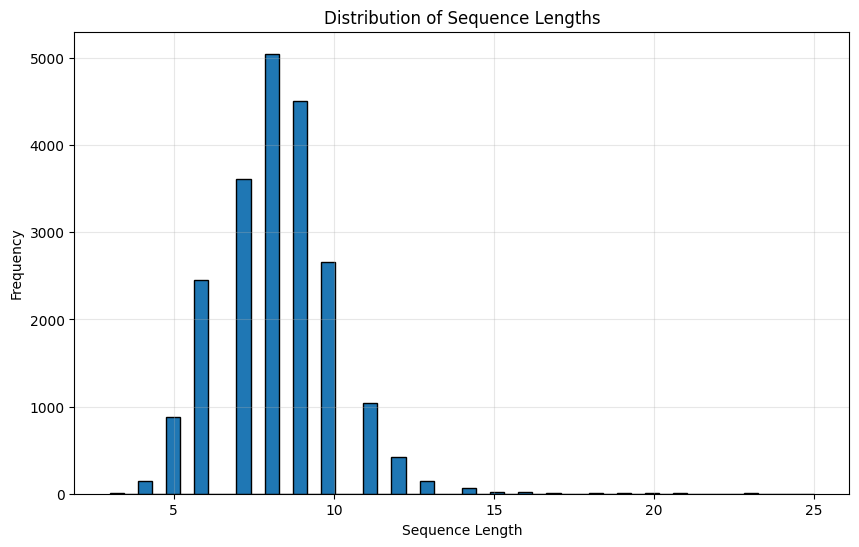

Min sequence length: 3
Max sequence length: 25
Mean sequence length: 8.22
Median sequence length: 8.00


In [13]:
# Sequence length distribution
sequence_lengths = [len(seq) for seq in sequences]
plt.figure(figsize=(10, 6))
plt.hist(sequence_lengths, bins=50, edgecolor='black')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.title('Distribution of Sequence Lengths')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Min sequence length: {min(sequence_lengths)}")
print(f"Max sequence length: {max(sequence_lengths)}")
print(f"Mean sequence length: {np.mean(sequence_lengths):.2f}")
print(f"Median sequence length: {np.median(sequence_lengths):.2f}")


## Sample Processed Sequences


In [14]:
# Display sample processed sequences
print("Sample Processed Sequences:")
print("=" * 50)
for i in range(min(5, len(X_train))):
    input_seq = X_train[i]
    output_token = y_train[i]

    # Convert back to text
    input_text = ' '.join([tokenizer.index_word.get(token, '<OOV>') for token in input_seq if token != 0])
    output_text = tokenizer.index_word.get(output_token, '<OOV>')

    print(f"\nSample {i+1}:")
    print(f"  Input: ...{input_text[-50:]}")  # Show last 50 chars
    print(f"  Output token: {output_text}")


Sample Processed Sequences:

Sample 1:
  Input: ...مرغے کی آواز سے بجتی گھر کی کنڈی جیسی
  Output token: ماں

Sample 2:
  Input: ...دو گھڑی کی چاہت میں لڑکیاں نہیں
  Output token: کھلتیں

Sample 3:
  Input: ...مہر گردوں ہے چراغ رہ گزار باد
  Output token: یاں

Sample 4:
  Input: ...جس بزم میں گئے یہی افسانہ ساتھ
  Output token: ہے

Sample 5:
  Input: ...میں ازل سے صبح محشر تک فروزاں ہی
  Output token: رہا
